# Implementation of Generative Forecasting using Joint Probability Models on KS PDE

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
from scipy.stats import wasserstein_distance
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict

In [2]:
dataset = np.load("/kaggle/input/datasets/theredatom/ks-1d-pde/ks_dataset_imex.npy")

In [3]:
class JointWindowDataset(Dataset):
    def __init__(self, trajectory, n=2, num_windows=1_000_000):
        self.trajectory = trajectory
        self.n = n
        self.num_windows = min(num_windows, len(trajectory) - n + 1)
        
        mean_per_trajectory = trajectory[:self.num_windows+(n-1)].mean(axis=0).astype(np.float32)
        std_per_trajectory = trajectory[:self.num_windows+(n-1)].std(axis=0).astype(np.float32)
        
        self.mean = np.tile(mean_per_trajectory,self.n)
        self.std = np.tile(std_per_trajectory,self.n) + 1e-8

    def __len__(self):
        return self.num_windows

    def __getitem__(self, idx):
        window = self.trajectory[idx:idx+self.n].reshape(-1)
        window = window.astype(np.float32)
        window = (window - self.mean) / self.std
        return torch.from_numpy(window)
        

In [4]:
train_dataset = JointWindowDataset(dataset, n=2, num_windows=1_000_000)

In [5]:
train_dataloader = DataLoader(train_dataset,batch_size=2000,shuffle=True,num_workers=4)

In [6]:
print(f'Number of time windows (samples) in the Training Dataset = {len(train_dataset)}')

Number of time windows (samples) in the Training Dataset = 1000000


In [7]:
class ContinuousNADE(nn.Module):
    def __init__(self,input_dim = 400, hidden_dim = 1500):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))

        self.V_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_mu = nn.Parameter(torch.zeros(input_dim))

        self.V_log_sigma = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_log_sigma = nn.Parameter(torch.zeros(input_dim))

    def forward(self,x):
        batch_size = x.shape[0]

        mu_outputs = torch.zeros_like(x)
        log_sigma_outputs = torch.zeros_like(x)

        a_i = self.c.repeat(batch_size,1)

        for i in range(self.input_dim):
            h_i = torch.relu(a_i)
            mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
            log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]
            log_sigma_i = torch.clamp(log_sigma_i, min=-5, max=2)
            mu_outputs[:, i] = mu_i
            log_sigma_outputs[:, i] = log_sigma_i

            if i < self.input_dim - 1:
                v_i = x[:, i].unsqueeze(1)
                W_i = self.W[:, i].unsqueeze(0)
                a_i = a_i + v_i * W_i

        return mu_outputs, log_sigma_outputs

    def sample(self):
        generated_sequence = torch.zeros(self.input_dim)
        a_i = self.c.clone()

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i = torch.relu(a_i)
                mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
                log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]

                sigma_i = torch.exp(log_sigma_i)
                sampled_value = mu_i + sigma_i * torch.randn(1, device=mu_i.device)
                generated_sequence[i] = sampled_value
                if i < self.input_dim - 1:
                    a_i = a_i + self.W[:, i] * sampled_value

        return generated_sequence


    def sample_batch(self,batch_size):
        device=self.c.device

        generated=torch.zeros(batch_size,self.input_dim,device=device)
        a_i=self.c.unsqueeze(0).repeat(batch_size,1)

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i=torch.relu(a_i)

                mu_i=h_i@self.V_mu[i]+self.b_mu[i]
                log_sigma_i=h_i@self.V_log_sigma[i]+self.b_log_sigma[i]
                log_sigma_i=torch.clamp(log_sigma_i,min=-5,max=2)

                sigma_i=torch.exp(log_sigma_i)

                sampled_values=mu_i+sigma_i*torch.randn(batch_size,device=device)

                generated[:,i]=sampled_values

                if i<self.input_dim-1:
                    a_i=a_i+sampled_values.unsqueeze(1)*self.W[:,i].unsqueeze(0)

        return generated

In [8]:
def gaussian_nll_loss(mu, log_sigma, target):
    variance = torch.exp(log_sigma) ** 2
    loss = 0.5 * ((target - mu) ** 2 / variance) + log_sigma + 0.5 * np.log(2 * np.pi)
    #Sum across the 6 dimensions, then get the mean for the batch
    return loss.sum(dim=1).mean()

In [ ]:
'''
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ContinuousNADE()

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model, device_ids=[0, 1])
    
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4) 
train_loss_history = []
epochs = 80
best_loss = float("inf")
save_path = "best_continuous_nade.pt"                      

# Simple Training Loop
for epoch in range(epochs):
    train_loss = 0.0
    model.train()
    
    for batch in train_dataloader:
        batch = batch.float().to(device)
        optimizer.zero_grad()
        mu_outputs, log_sigma_outputs = model(batch)
        loss = gaussian_nll_loss(mu_outputs, log_sigma_outputs, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        
    avg_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        
        if isinstance(model, nn.DataParallel):
            model_state = model.module.state_dict()
        else:
            model_state = model.state_dict()
            
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_loss": best_loss,
            "train_loss_history": train_loss_history
        }, save_path)
        print(f"Saved best model at epoch {epoch+1} | Loss: {best_loss:.4f}")
    if (epoch+1)%5 == 0:
        print(f'Epoch {epoch+1}/{epochs} | Avg Train Loss: {avg_loss:.4f}')
'''

In [9]:
test_idx = int(1e6)
available_ground_truth = dataset[test_idx:test_idx+2].reshape(-1)
available_ground_truth = available_ground_truth.astype(np.float32)
print(available_ground_truth.shape)

(400,)


In [10]:
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint=torch.load("/kaggle/input/models/abhishekrreddy/ks-nade/pytorch/default/1/Continuous_Nade_EP80_HL1500.pt",map_location=device)
model=ContinuousNADE(input_dim=400,hidden_dim=1500).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

ContinuousNADE()

In [11]:
total_samples = int(1e6)
chunk_size = int(8e4)
samples = []
with torch.no_grad():
    for i in range(0, total_samples, chunk_size):
        current_chunk_size = min(chunk_size, total_samples - i)
        batch_samples = model.sample_batch(current_chunk_size).cpu()
        samples.append(batch_samples)
        torch.cuda.empty_cache()
samples = torch.cat(samples, dim=0)

In [12]:
generated_time_window_samples = samples.detach().cpu().numpy().astype(np.float32)

print(generated_time_window_samples.shape)

np.save("generated_time_window_samples.npy", generated_time_window_samples)

(1000000, 400)


In [13]:
candidates = torch.from_numpy(generated_time_window_samples).float().to("cpu")
mu_tensor = torch.tensor(train_dataset.mean, device=candidates.device)
std_tensor = torch.tensor(train_dataset.std, device=candidates.device)
unnormalized_candidates = (candidates * std_tensor) + mu_tensor
candidate_tails = unnormalized_candidates[:, :200]
candidate_heads = unnormalized_candidates[:, 200:]

In [20]:
start_idx = 1000000 
end_idx = 4000000
num_samples = 500

#Creating 500 base points equally spaced (every 6000 steps)
base_points = np.linspace(start_idx, end_idx - 1000, num_samples).astype(int)
random_offsets = np.random.randint(0, 1000, size=num_samples)
test_start_indices = base_points + random_offsets
print(f"First 5 indices: {test_start_indices[:5]}")

First 5 indices: [1000891 1006289 1012500 1018939 1024868]


# Calculation of UQ Metrics

In [14]:
def get_ensemble_variance(ensemble_heads):
    var_per_dim = torch.var(ensemble_heads,dim=0)
    return torch.mean(var_per_dim).item()

In [23]:
def get_autocorrelation(ensemble_tails, ensemble_heads):
    ac_dims = []

    for d in range(ensemble_tails.shape[1]):
        t_vals = ensemble_tails[:, d]
        h_vals = ensemble_heads[:, d]

        t_mean = torch.mean(t_vals)
        h_mean = torch.mean(h_vals)

        t_std = torch.std(t_vals)
        h_std = torch.std(h_vals)

        numerator = torch.mean((t_vals - t_mean) * (h_vals - h_mean))
        denominator = t_std * h_std

        if denominator > 1e-8:
            ac_dims.append(numerator / denominator)
        else:
            ac_dims.append(torch.tensor(0.0, device=ensemble_tails.device))

    return torch.mean(torch.stack(ac_dims)).item()

In [24]:
from scipy.stats import wasserstein_distance

def get_wasserstien_drift(current_tails, prev_heads):
    tails_np = current_tails.detach().cpu().numpy()
    heads_np = prev_heads.detach().cpu().numpy()

    drifts = []

    for d in range(tails_np.shape[1]):
        d_dist = wasserstein_distance(tails_np[:, d], heads_np[:, d])
        drifts.append(d_dist)

    return np.mean(drifts)

In [25]:
def get_signed_drift(wd_value, current_var, prev_var):
    if current_var<prev_var:
        return -wd_value
    else:
        return wd_value

In [ ]:
k = 50 # Number of neighbors to form the ensemble
num_test_trajectories = 500
steps = 100

all_variance = np.zeros((num_test_trajectories, steps))
all_autocorr = np.zeros((num_test_trajectories, steps))
all_drift = np.zeros((num_test_trajectories, steps))
all_mae_pertraj = np.zeros((num_test_trajectories, steps))

In [32]:
candidate_tails = candidate_tails.to(device)
candidate_heads = candidate_heads.to(device)

In [ ]:
for traj_idx, start_idx in enumerate(test_start_indices):
    if start_idx + steps > len(dataset):
        continue        
    current_state = torch.tensor(dataset[start_idx], device=device, dtype=torch.float32)
    prev_ensemble_heads = current_state.unsqueeze(0).expand(k, -1).clone()
    prev_var = 0.0
    cumulative_wd = 0.0

    truth = dataset[start_idx+1: start_idx + steps+1]
    
    for step in range(steps):
        with torch.no_grad():
            distances = torch.norm(candidate_tails - current_state, dim=1)
            _, topk_indices = torch.topk(distances, k=k, largest=False)            
            ensemble_tails = candidate_tails[topk_indices]
            ensemble_heads = candidate_heads[topk_indices]            
            # 1. Variance
            current_var = get_ensemble_variance(ensemble_heads)
            all_variance[traj_idx, step] = current_var
            
            # 2. Autocorrelation
            all_autocorr[traj_idx, step] = get_autocorrelation(ensemble_tails, ensemble_heads)
            
            # 3. Wasserstein Drift (Ensemble vs Ensemble)
            wd_raw = get_wasserstien_drift(ensemble_tails, prev_ensemble_heads)
            
            # 4. Signed & Cumulative Drift
            signed_wd = get_signed_drift(wd_raw, current_var, prev_var)
            cumulative_wd += signed_wd
            all_drift[traj_idx, step] = cumulative_wd

            gt_step = torch.tensor(truth[step], device=device, dtype=torch.float32)
                        
            # Update for next iteration
            winning_head = ensemble_heads[0]

            all_mae_pertraj[traj_idx, step] = torch.mean(torch.abs(winning_head - gt_step)).item()

            
            current_state = winning_head
            prev_ensemble_heads = ensemble_heads
            prev_var = current_var

    if (traj_idx + 1) % 50 == 0:
        print(f"Processed {traj_idx + 1}/{num_test_trajectories} trajectories")

Processed 50/500 trajectories
Processed 100/500 trajectories
Processed 150/500 trajectories
Processed 200/500 trajectories
Processed 250/500 trajectories
Processed 300/500 trajectories
Processed 350/500 trajectories
Processed 400/500 trajectories
Processed 450/500 trajectories


In [53]:
def linear_regressor(X, y):
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r, _ = pearsonr(y, y_pred)
    return r

In [54]:
rho_var, rho_ac, rho_wd, rho_all = [], [], [], []

In [55]:
for i in range(num_test_trajectories):
    y =all_mae_pertraj[i]                              
    X_var=all_variance[i].reshape(-1, 1)
    X_ac=all_autocorr[i].reshape(-1, 1)
    X_wd =all_drift[i].reshape(-1, 1)
    X_all=np.stack([all_variance[i], all_autocorr[i], all_drift[i]], axis=1)

    rho_var.append(linear_regressor(X_var, y))
    rho_ac .append(linear_regressor(X_ac,  y))
    rho_wd .append(linear_regressor(X_wd,  y))
    rho_all.append(linear_regressor(X_all, y))

/tmp/ipykernel_58/1804676040.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(y, y_pred)
/tmp/ipykernel_58/1804676040.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(y, y_pred)
/tmp/ipykernel_58/1804676040.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(y, y_pred)
/tmp/ipykernel_58/1804676040.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(y, y_pred)


In [56]:
rho_var = np.array(rho_var)
rho_ac = np.array(rho_ac)
rho_wd = np.array(rho_wd)
rho_all = np.array(rho_all)

rho_var = rho_var[np.isfinite(rho_var)]
rho_ac = rho_ac[np.isfinite(rho_ac)]
rho_wd = rho_wd[np.isfinite(rho_wd)]
rho_all = rho_all[np.isfinite(rho_all)]

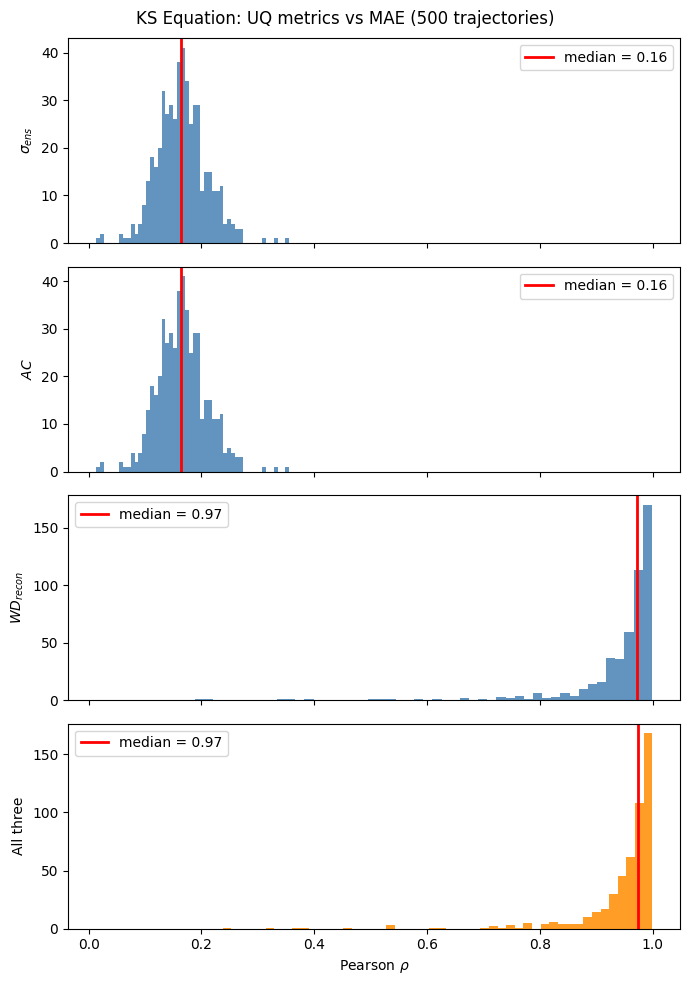

In [57]:
fig, axes = plt.subplots(4, 1, figsize=(7, 10), sharex=True)

for ax, rho, label, color in zip(
    axes,
    [rho_var, rho_ac, rho_wd, rho_all],
    [r'$\sigma_{ens}$', r'$AC$', r'$WD_{recon}$', 'All three'],
    ['steelblue', 'steelblue', 'steelblue', 'darkorange'],
):
    ax.hist(rho, bins=50, color=color, alpha=0.85)
    med = np.median(rho)
    ax.axvline(med, color='red', lw=2, label=f'median = {med:.2f}')
    ax.set_ylabel(label)
    ax.legend()

axes[-1].set_xlabel(r'Pearson $\rho$')
fig.suptitle('KS Equation: UQ metrics vs MAE (500 trajectories)', fontsize=12)
plt.tight_layout()
plt.show()